<a href="https://colab.research.google.com/github/Najwaalya/PCVK_Ganjil_2025/blob/main/Modul6_Histogram%2C_Histogram_Equalization%2C_Dithering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library Dasar

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

## Membuat Histogram Manual (Grayscale & RGB)

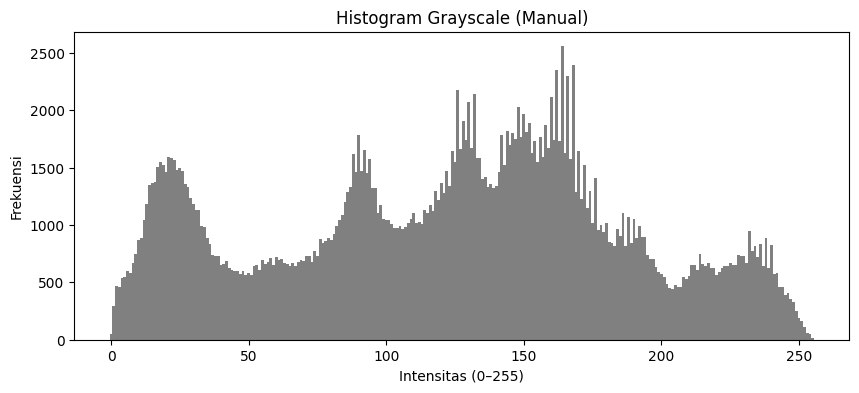

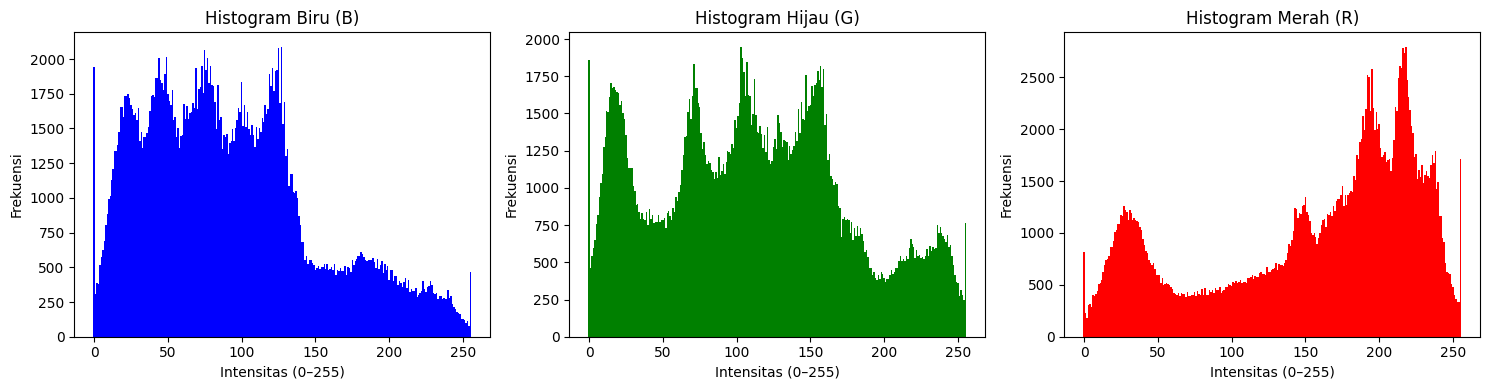

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Membaca gambar dan ubah ke grayscale ---
img = cv2.imread('lena.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Histogram Grayscale (Manual) ---
hist_gray = np.zeros(256)
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        hist_gray[gray[i, j]] += 1

plt.figure(figsize=(10,4))
plt.title("Histogram Grayscale (Manual)")
plt.xlabel("Intensitas (0–255)")
plt.ylabel("Frekuensi")
plt.bar(np.arange(256), hist_gray, color='gray', width=1)
plt.show()

# --- Histogram RGB Manual (Bar Chart Per Channel) ---
colors = ('b', 'g', 'r')
titles = ('Histogram Biru (B)', 'Histogram Hijau (G)', 'Histogram Merah (R)')

plt.figure(figsize=(15,4))

for idx, col in enumerate(colors):
    hist = np.zeros(256)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            hist[img[y, x, idx]] += 1

    plt.subplot(1, 3, idx+1)
    plt.bar(np.arange(256), hist, color=col, width=1)
    plt.title(titles[idx])
    plt.xlabel('Intensitas (0–255)')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## Histogram dengan NumPy

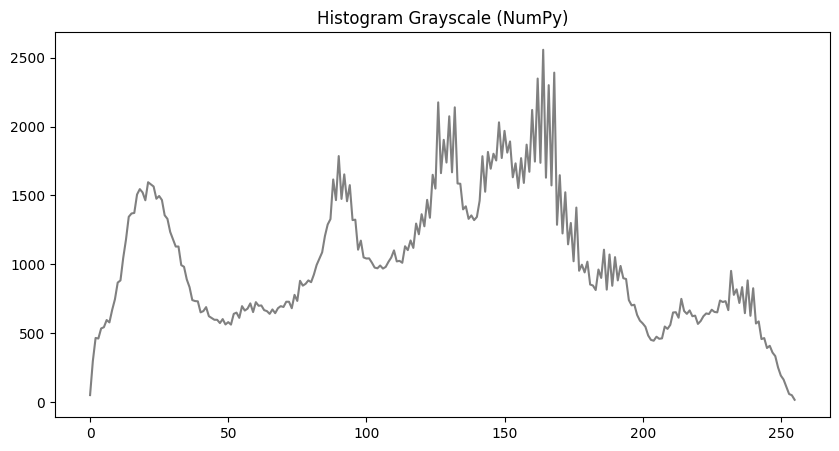

In [8]:
# Histogram dengan NumPy
hist_np, bins = np.histogram(gray.flatten(), 256, [0,256])

plt.figure(figsize=(10,5))
plt.title("Histogram Grayscale (NumPy)")
plt.plot(hist_np, color='gray')
plt.show()

## Histogram Equalization (Manual)

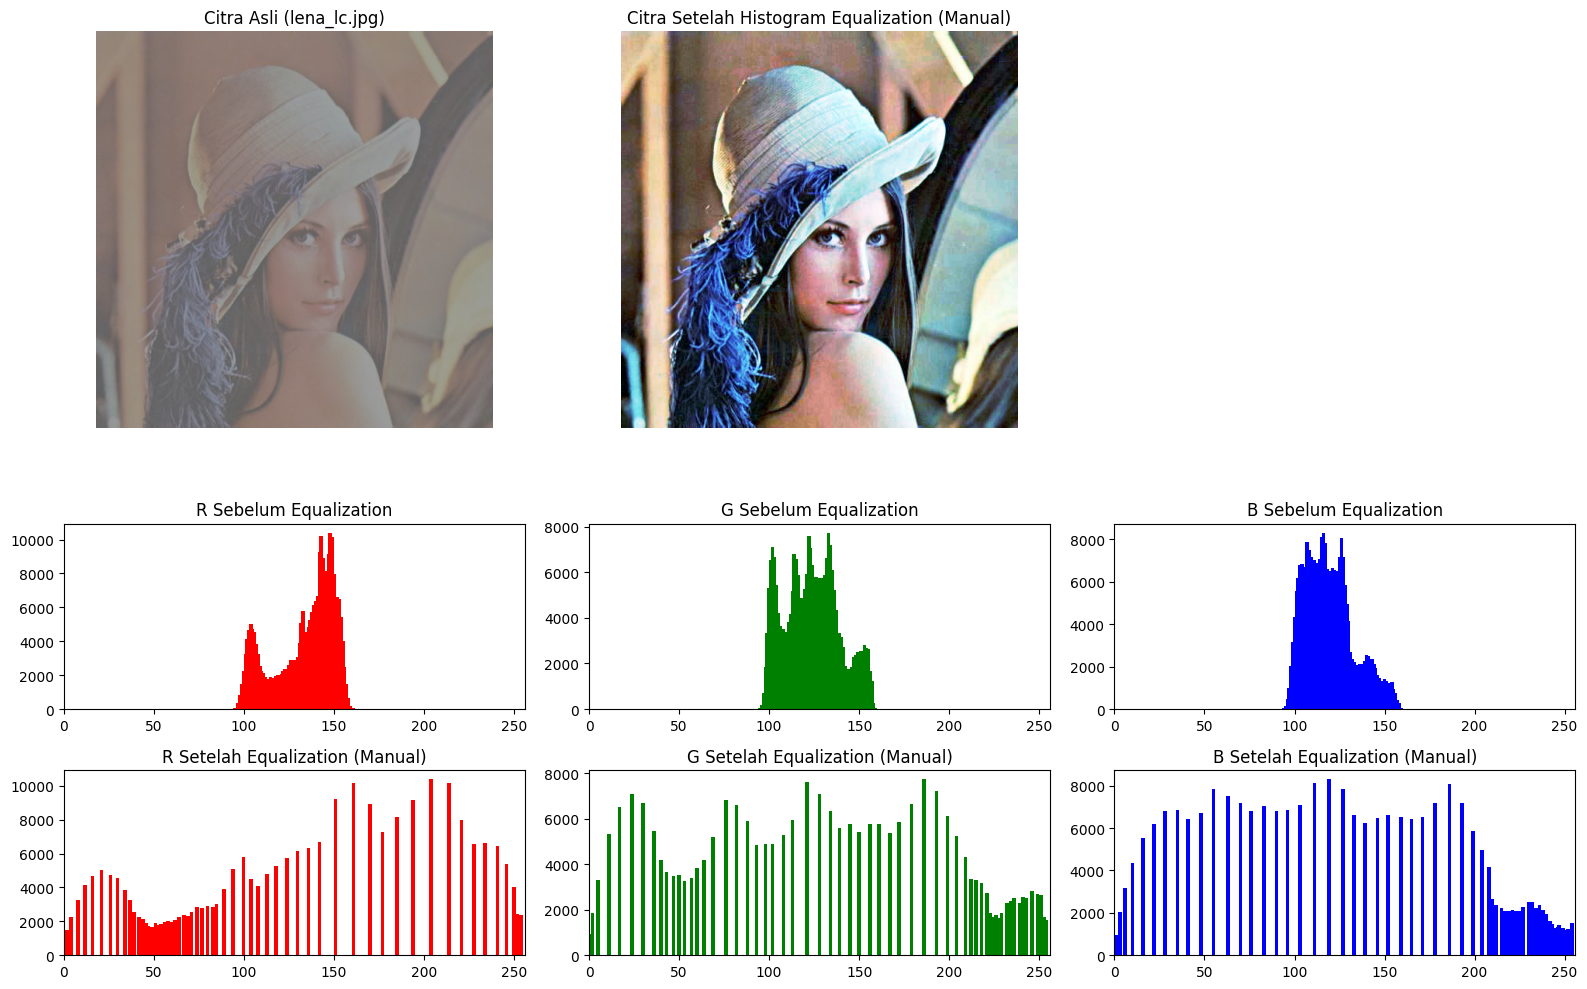

In [9]:
# --- 1. Input Image (Baca dan ubah ke RGB) ---
img = cv2.imread('lena_lc.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- 2. Pisahkan channel R, G, B ---
r, g, b = cv2.split(img_rgb)

# --- 3. Fungsi manual untuk histogram equalization ---
def manual_equalize(channel):
    # Hitung histogram
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])
    # Hitung distribusi kumulatif (CDF)
    cdf = hist.cumsum()
    # Masking nilai 0 agar tidak memengaruhi normalisasi
    cdf_m = np.ma.masked_equal(cdf, 0)
    # Normalisasi CDF ke skala 0–255 (rumus K0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    # Isi nilai kosong kembali (0)
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    # Transformasi nilai piksel lama ke nilai baru
    img_eq = cdf_final[channel]
    return img_eq, hist, cdf_final

# --- 4. Terapkan ke masing-masing channel ---
r_eq, hist_r, cdf_r = manual_equalize(r)
g_eq, hist_g, cdf_g = manual_equalize(g)
b_eq, hist_b, cdf_b = manual_equalize(b)

# --- 5. Gabungkan kembali ke RGB ---
img_eq = cv2.merge((r_eq, g_eq, b_eq))

# --- 6. Hitung histogram hasil equalization ---
hist_r_eq = cv2.calcHist([r_eq], [0], None, [256], [0,256])
hist_g_eq = cv2.calcHist([g_eq], [0], None, [256], [0,256])
hist_b_eq = cv2.calcHist([b_eq], [0], None, [256], [0,256])

# --- 7. Tampilkan hasil ---
plt.figure(figsize=(16,10))

# Citra sebelum dan sesudah
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Citra Asli (lena_lc.jpg)")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(img_eq)
plt.title("Citra Setelah Histogram Equalization (Manual)")
plt.axis('off')

# Histogram sebelum
plt.subplot(4,3,7)
plt.bar(np.arange(256), hist_r, color='red', width=2)
plt.title("R Sebelum Equalization")
plt.xlim([0,256])

plt.subplot(4,3,8)
plt.bar(np.arange(256), hist_g, color='green', width=2)
plt.title("G Sebelum Equalization")
plt.xlim([0,256])

plt.subplot(4,3,9)
plt.bar(np.arange(256), hist_b, color='blue', width=2)
plt.title("B Sebelum Equalization")
plt.xlim([0,256])

# Histogram sesudah
plt.subplot(4,3,10)
plt.bar(np.arange(256), hist_r_eq[:,0], color='red', width=2)
plt.title("R Setelah Equalization (Manual)")
plt.xlim([0,256])

plt.subplot(4,3,11)
plt.bar(np.arange(256), hist_g_eq[:,0], color='green', width=2)
plt.title("G Setelah Equalization (Manual)")
plt.xlim([0,256])

plt.subplot(4,3,12)
plt.bar(np.arange(256), hist_b_eq[:,0], color='blue', width=2)
plt.title("B Setelah Equalization (Manual)")
plt.xlim([0,256])

plt.tight_layout()
plt.show()

## Histogram Equalization dengan OpenCV

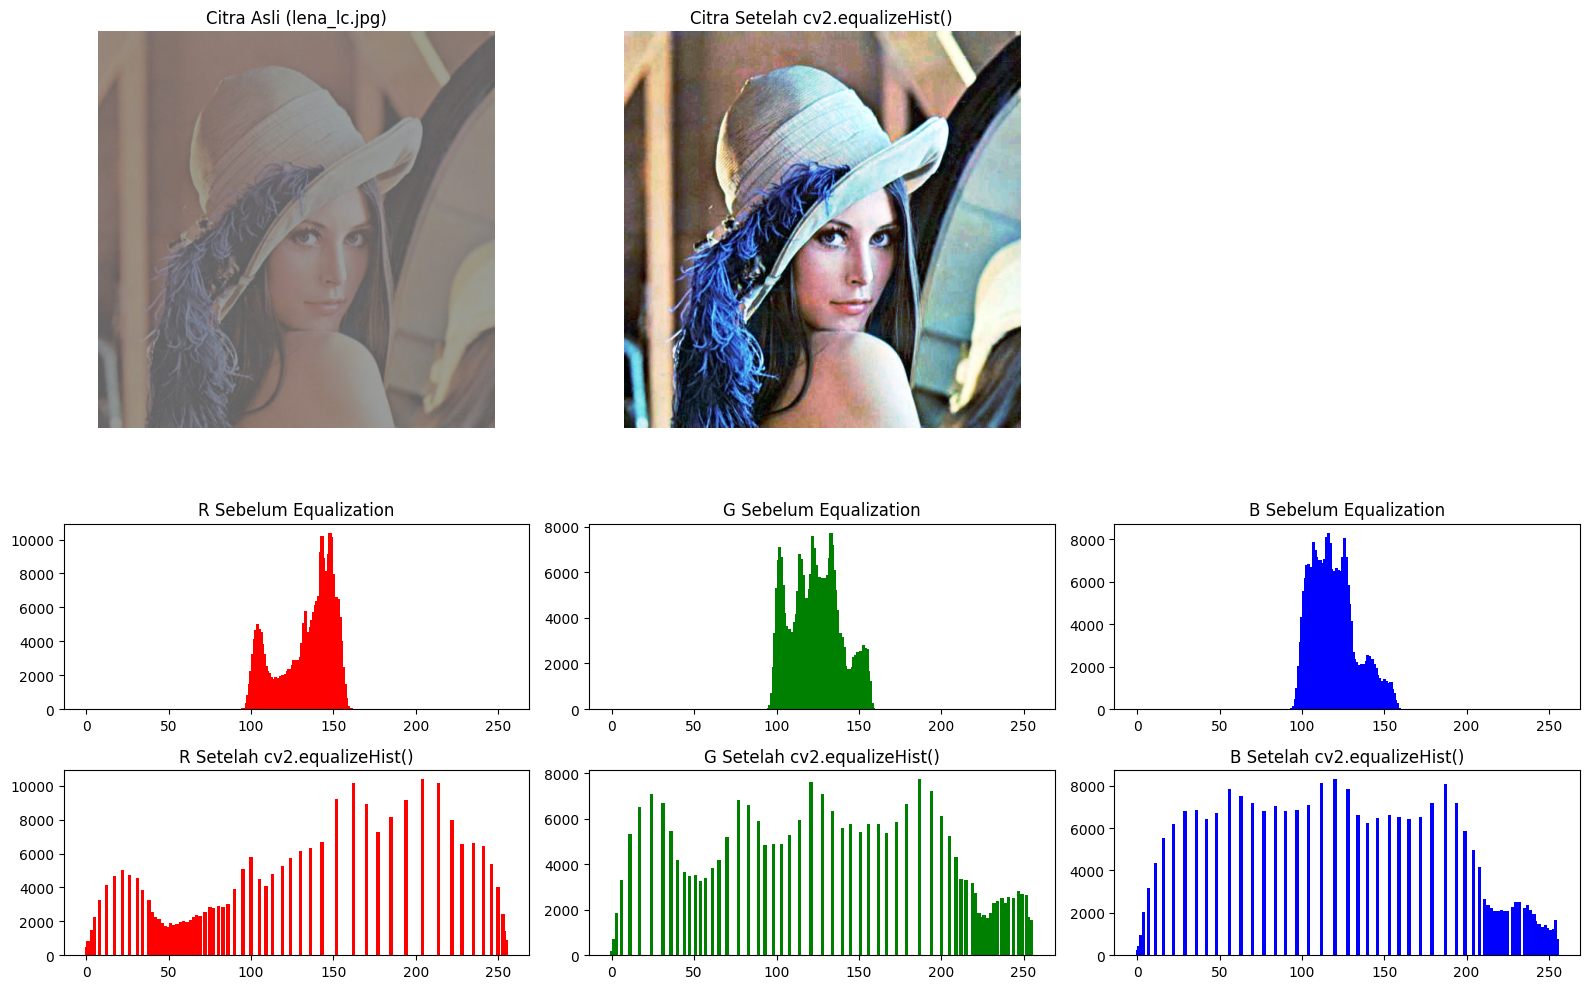

In [10]:
# --- Baca gambar berwarna ---
img = cv2.imread('lena_lc.jpg')

# Konversi ke RGB (agar warnanya benar di matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv2.split(img_rgb)

# Terapkan cv2.equalizeHist() ke tiap channel
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

# Gabungkan hasil equalization
img_eq = cv2.merge((r_eq, g_eq, b_eq))

# Hitung histogram sebelum dan sesudah
hist_r = cv2.calcHist([r], [0], None, [256], [0,256])
hist_g = cv2.calcHist([g], [0], None, [256], [0,256])
hist_b = cv2.calcHist([b], [0], None, [256], [0,256])

hist_r_eq = cv2.calcHist([r_eq], [0], None, [256], [0,256])
hist_g_eq = cv2.calcHist([g_eq], [0], None, [256], [0,256])
hist_b_eq = cv2.calcHist([b_eq], [0], None, [256], [0,256])

# --- Tampilkan hasil ---
plt.figure(figsize=(16,10))

# Sebelum dan sesudah equalization
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Citra Asli (lena_lc.jpg)")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(img_eq)
plt.title("Citra Setelah cv2.equalizeHist()")
plt.axis('off')

# Histogram sebelum
plt.subplot(4,3,7)
plt.bar(np.arange(256), hist_r[:,0], color='red', width=2)
plt.title("R Sebelum Equalization")

plt.subplot(4,3,8)
plt.bar(np.arange(256), hist_g[:,0], color='green', width=2)
plt.title("G Sebelum Equalization")

plt.subplot(4,3,9)
plt.bar(np.arange(256), hist_b[:,0], color='blue', width=2)
plt.title("B Sebelum Equalization")

# Histogram sesudah
plt.subplot(4,3,10)
plt.bar(np.arange(256), hist_r_eq[:,0], color='red', width=2)
plt.title("R Setelah cv2.equalizeHist()")

plt.subplot(4,3,11)
plt.bar(np.arange(256), hist_g_eq[:,0], color='green', width=2)
plt.title("G Setelah cv2.equalizeHist()")

plt.subplot(4,3,12)
plt.bar(np.arange(256), hist_b_eq[:,0], color='blue', width=2)
plt.title("B Setelah cv2.equalizeHist()")

plt.tight_layout()
plt.show()

## Pemetaan RGB ke 8 Warna (Color Quantization)

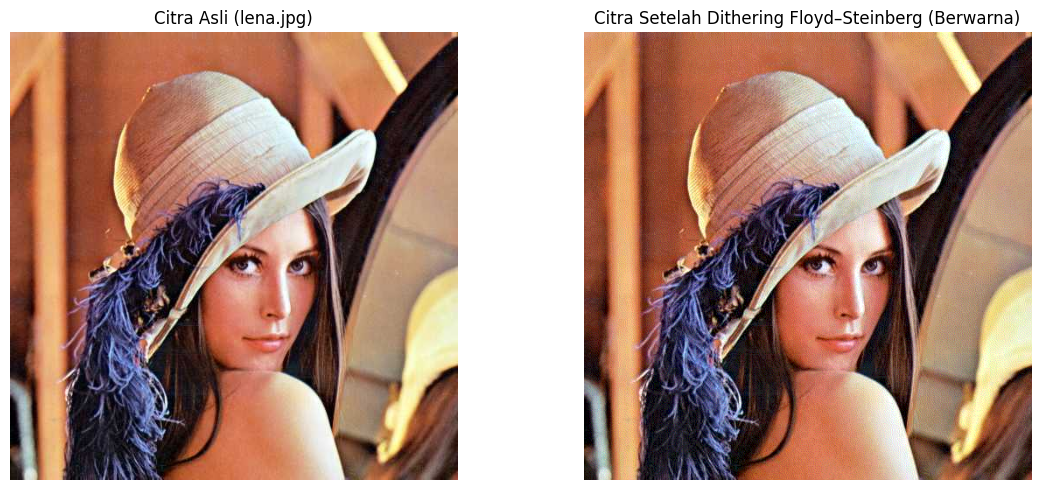

In [17]:
# --- 1. Input Image ---
img = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- 2. Definisikan 8 warna utama (RGB) ---
colors = np.array([
    [0, 0, 0],         # Hitam
    [255, 0, 0],       # Merah
    [0, 255, 0],       # Hijau
    [0, 0, 255],       # Biru
    [255, 255, 0],     # Kuning
    [0, 255, 255],     # Cyan
    [255, 0, 255],     # Magenta
    [255, 255, 255]    # Putih
], dtype=np.uint8)

# --- 3. Buat fungsi untuk mencari warna terdekat dari 8 warna tersebut ---
def map_to_nearest_color(pixel):
    # Hitung jarak Euclidean antara piksel dan setiap warna dasar
    distances = np.sqrt(np.sum((colors - pixel)**2, axis=1))
    nearest_idx = np.argmin(distances)
    return colors[nearest_idx]

# --- 4. Terapkan fungsi ke seluruh piksel citra ---
h, w, c = img_rgb.shape
quantized_img = np.zeros_like(img_rgb)

for y in range(h):
    for x in range(w):
        quantized_img[y, x] = map_to_nearest_color(img_rgb[y, x])

# --- 5. Tampilkan hasil ---
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Citra Asli (16 juta warna)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(quantized_img)
plt.title("Citra Setelah Pemetaan ke 8 Warna")
plt.axis('off')

plt.tight_layout()
plt.show()

## Dithering Floyd–Steinberg

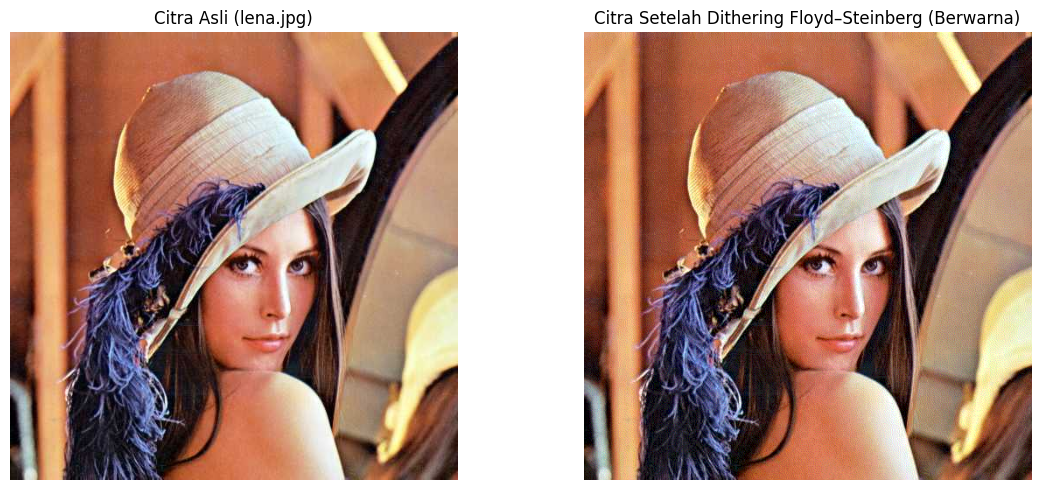

In [18]:
# --- 1. Input Image ---
img = cv2.imread('lena.jpg')

# Ubah ke RGB biar tampilannya benar di matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype(float)

# --- 2. Tentukan jarak warna (semakin kecil = lebih banyak warna) ---
jarakPixel = 8   # sesuai flowchart → batasan warna (quantization step)

# --- 3. Floyd–Steinberg Dithering sesuai flowchart ---
h, w, c = img.shape

for y in range(h - 1):            # looping y dari 0 → height - 1
    for x in range(1, w - 1):     # looping x dari 1 → width - 1

        # Ambil nilai pixel lama (per channel)
        old_pixel = img[y, x].copy()
        pixelBlueOld, pixelGreenOld, pixelRedOld = old_pixel

        # Hitung pixel baru berdasar quantization level (jarakPixel)
        pixelBlueNew  = np.round(jarakPixel * pixelBlueOld  / 255.0) * (255.0 / jarakPixel)
        pixelGreenNew = np.round(jarakPixel * pixelGreenOld / 255.0) * (255.0 / jarakPixel)
        pixelRedNew   = np.round(jarakPixel * pixelRedOld   / 255.0) * (255.0 / jarakPixel)

        # Update piksel baru
        img[y, x, 0] = pixelBlueNew
        img[y, x, 1] = pixelGreenNew
        img[y, x, 2] = pixelRedNew

        # Hitung kuantisasi error
        errorBlue  = pixelBlueOld  - pixelBlueNew
        errorGreen = pixelGreenOld - pixelGreenNew
        errorRed   = pixelRedOld   - pixelRedNew

        # Sebarkan error ke piksel tetangga sesuai rumus Floyd–Steinberg
        if x + 1 < w:
            img[y, x + 1, 0] += errorBlue  * 7 / 16
            img[y, x + 1, 1] += errorGreen * 7 / 16
            img[y, x + 1, 2] += errorRed   * 7 / 16
        if y + 1 < h and x > 0:
            img[y + 1, x - 1, 0] += errorBlue  * 3 / 16
            img[y + 1, x - 1, 1] += errorGreen * 3 / 16
            img[y + 1, x - 1, 2] += errorRed   * 3 / 16
        if y + 1 < h:
            img[y + 1, x, 0] += errorBlue  * 5 / 16
            img[y + 1, x, 1] += errorGreen * 5 / 16
            img[y + 1, x, 2] += errorRed   * 5 / 16
        if y + 1 < h and x + 1 < w:
            img[y + 1, x + 1, 0] += errorBlue  * 1 / 16
            img[y + 1, x + 1, 1] += errorGreen * 1 / 16
            img[y + 1, x + 1, 2] += errorRed   * 1 / 16

# --- 4. Normalisasi hasil agar tetap dalam rentang 0–255 ---
dithered = np.clip(img, 0, 255).astype(np.uint8)

# --- 5. Tampilkan hasil ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(cv2.imread('lena.jpg'), cv2.COLOR_BGR2RGB))
plt.title("Citra Asli (lena.jpg)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dithered)
plt.title("Citra Setelah Dithering Floyd–Steinberg (Berwarna)")
plt.axis('off')

plt.tight_layout()
plt.show()

## Histogram Equalization + Dithering

Silakan upload file 'lena_lc.jpg' dari komputer kamu:


Saving lena_lc.jpg to lena_lc (6).jpg


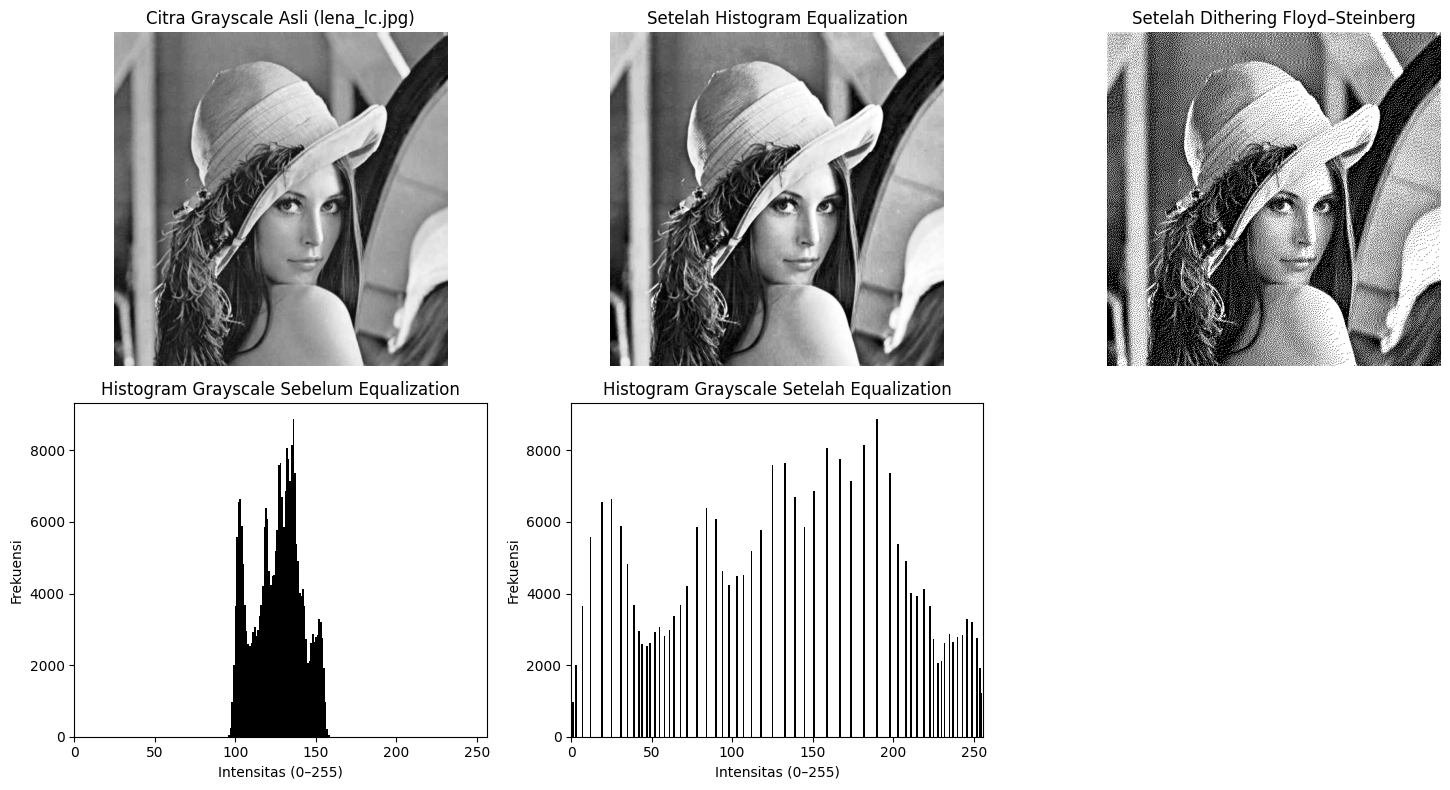

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- 1️⃣ Upload gambar lena_lc.jpg ---
print("Silakan upload file 'lena_lc.jpg' dari komputer kamu:")
uploaded = files.upload()

# --- 2️⃣ Baca gambar dan ubah ke grayscale ---
img = cv2.imread('lena_lc.jpg')
if img is None:
    raise ValueError("Gambar tidak ditemukan!")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- 3️⃣ Terapkan Histogram Equalization ---
equalized = cv2.equalizeHist(gray)

# --- 4️⃣ Fungsi Floyd–Steinberg Dithering (grayscale) ---
def floyd_steinberg_dither(image):
    img = image.astype(float)
    h, w = img.shape
    for y in range(h):
        for x in range(w):
            old_pixel = img[y, x]
            new_pixel = 255 if old_pixel > 128 else 0  # threshold biner
            img[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke piksel sekitar (kernel Floyd–Steinberg)
            if x + 1 < w:
                img[y, x + 1] += error * 7 / 16
            if y + 1 < h and x > 0:
                img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < h:
                img[y + 1, x] += error * 5 / 16
            if y + 1 < h and x + 1 < w:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

# --- 5️⃣ Terapkan dithering pada hasil equalization ---
dithered = floyd_steinberg_dither(equalized.copy())

# --- 6️⃣ Hitung histogram grayscale sebelum dan sesudah equalization ---
hist_gray = cv2.calcHist([gray], [0], None, [256], [0,256])
hist_eq = cv2.calcHist([equalized], [0], None, [256], [0,256])

# --- 7️⃣ Tampilkan hasil ---
plt.figure(figsize=(15,8))

# Baris 1 - Gambar
plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Grayscale Asli (lena_lc.jpg)')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(equalized, cmap='gray')
plt.title('Setelah Histogram Equalization')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(dithered, cmap='gray')
plt.title('Setelah Dithering Floyd–Steinberg')
plt.axis('off')

# Baris 2 - Histogram Batang
plt.subplot(2,3,4)
plt.bar(np.arange(256), hist_gray[:,0], color='black', width=1.0)
plt.title('Histogram Grayscale Sebelum Equalization')
plt.xlabel('Intensitas (0–255)')
plt.ylabel('Frekuensi')
plt.xlim([0,256])

plt.subplot(2,3,5)
plt.bar(np.arange(256), hist_eq[:,0], color='black', width=1.0)
plt.title('Histogram Grayscale Setelah Equalization')
plt.xlabel('Intensitas (0–255)')
plt.ylabel('Frekuensi')
plt.xlim([0,256])

plt.tight_layout()
plt.show()